In [1]:
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scipy.stats as stats
import matplotlib.animation as animation
import os
from IPython.display import Video, display

In [2]:
brake_df = pd.read_csv("Brake_test_CSVs/Linear Accelerometer.csv")
auto_df = pd.read_csv("auto_cross_CSVs/Linear Accelerometer.csv")

In [3]:
def gg_plotter (a_x, a_y):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(a_x, a_y, color='red')
    ax.set_xlim(-2,2)
    ax.set_ylim(-2,2)

    ax.axhline(0, linewidth=1, color='black')
    ax.axvline(0, linewidth=1, color='black')

    # concentric circles every 0.5
    radii = np.arange(0.5, 2.1, 0.5)
    theta = np.linspace(0, 2*np.pi, 400)

    for r in radii:
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        ax.plot(x, y, color='gray', linewidth=0.7, alpha=0.7)

    ax.set_aspect('equal', 'box')
    plt.show(fig)

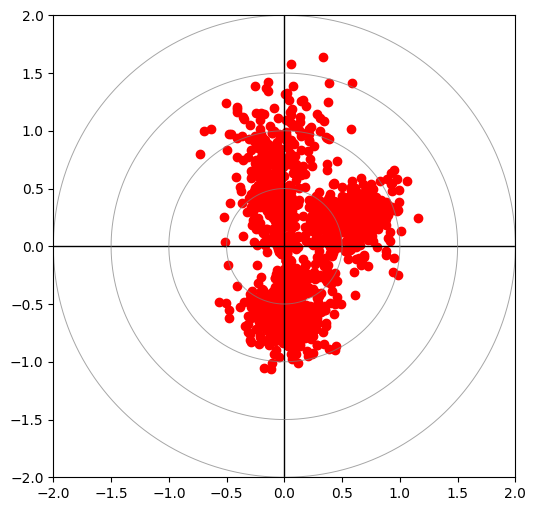

In [4]:
ax_brake = -1*brake_df["Y (m/s^2)"]/9.8
ay_brake = -1*brake_df["X (m/s^2)"]/9.8
gg_plotter(ax_brake, ay_brake)

In [6]:
def gg_animation (a_x, a_y, fps, output_file):
    frame_size = 600
    half_frame = frame_size // 2
    scale = 100  # pixels per g

    gg_brake = cv2.VideoWriter(output_file, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_size, frame_size))

    # Precompute circles
    radii = [0.5, 1.0, 1.5, 2.0]  # in g
    circle_pts = 400
    theta = np.linspace(0, 2*np.pi, circle_pts)
    circle_coords = [(r, np.cos(theta)*r, np.sin(theta)*r) for r in radii]

    # Font settings for OpenCV text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    font_color = (0, 0, 0)
    thickness = 1

    for i in range(len(brake_df)):
        # Blank white background
        frame = np.ones((frame_size, frame_size, 3), dtype=np.uint8) * 255

        # Draw axes
        cv2.line(frame, (0, half_frame), (frame_size, half_frame), (0,0,0), 1)
        cv2.line(frame, (half_frame, 0), (half_frame, frame_size), (0,0,0), 1)

        # Draw axis labels
        cv2.putText(frame, 'X (g)', (frame_size-50, half_frame-5), font, font_scale, font_color, thickness)
        cv2.putText(frame, 'Y (g)', (half_frame+5, 15), font, font_scale, font_color, thickness)

        # Draw concentric circles and their magnitude labels
        for r, x_circle, y_circle in circle_coords:
            pts = np.vstack([
                (x_circle * scale + half_frame).astype(np.int32),
                (-y_circle * scale + half_frame).astype(np.int32)
            ]).T
            pts = pts.reshape((-1,1,2))
            cv2.polylines(frame, [pts], isClosed=True, color=(200,200,200), thickness=1)

            # Label at positive X-axis
            label_pos = (int(half_frame + r * scale) + 5, half_frame - 5)
            cv2.putText(frame, f'{r:.1f}', label_pos, font, font_scale, font_color, thickness)

        # Plot the point
        x = a_x.iloc[i]
        y = a_y.iloc[i]
        px = int(x * scale + half_frame)
        py = int(y * scale + half_frame)
        cv2.circle(frame, (px, py), 5, (0,0,255), -1)

        # Write frame to video
        gg_brake.write(frame)
    gg_brake.release()


In [7]:
gg_animation(ax_brake, ay_brake, fps=20, output_file='gg_brake.mp4')